In [1]:
#Install Dependencies
!pip install imagehash

In [2]:
#Import Libs
import os
import io
import csv
import cv2
import hashlib
import imagehash
import numpy as np
import pandas as pd
import urllib.parse
import urllib.request

In [3]:
#Load Libs
from PIL import Image
from scipy.spatial import *
from matplotlib import pyplot as plot

In [4]:
#Warning Fix
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [5]:
# Datasets
url_lenna = 'https://raw.githubusercontent.com/jrafa1607/Evaluation-of-Perceptual-Hash-Algorithms/main/Hamming%20Distance%20Values/lennadatabase.csv'
url_mountain = 'https://raw.githubusercontent.com/jrafa1607/Evaluation-of-Perceptual-Hash-Algorithms/main/Hamming%20Distance%20Values/mountaindatabase.csv'
url_palace = 'https://raw.githubusercontent.com/jrafa1607/Evaluation-of-Perceptual-Hash-Algorithms/main/Hamming%20Distance%20Values/palacedatabase.csv'
url_park = 'https://raw.githubusercontent.com/jrafa1607/Evaluation-of-Perceptual-Hash-Algorithms/main/Hamming%20Distance%20Values/parkdatabase.csv'
url_washington = 'https://raw.githubusercontent.com/jrafa1607/Evaluation-of-Perceptual-Hash-Algorithms/main/Hamming%20Distance%20Values/washingtondatabase.csv'

In [6]:
# Import Datasets
lenna = pd.read_csv(url_lenna, delimiter=';', encoding='unicode_escape')
mountain = pd.read_csv(url_mountain, delimiter=';', encoding='unicode_escape')
palace = pd.read_csv(url_palace, delimiter=';', encoding='unicode_escape')
park = pd.read_csv(url_park, delimiter=';', encoding='unicode_escape')
washington = pd.read_csv(url_washington, delimiter=';', encoding='unicode_escape')

## Experiment Description: Evaluation of Perceptual Hash Algorithms

This experiment aims to **evaluate, compare, and measure the robustness of different hashing algorithms** in detecting visual similarity between images.

### 📌 Experiment Concept

The workflow is based on the comparative analysis of a pair of images:

* **Original Image:** The base version, intact and without modifications to the scene or object.
* **Modified / Altered Image:** A version that has undergone visual transformations (such as edge enhancement, filters, compression, or color changes).

---

### 🔍 Execution Steps

1. **Loading and Preprocessing:**
* Importing the original and altered images from external sources.
* Converting formats and color spaces to ensure compatibility with processing libraries.


2. **Signature Extraction (Hashing):**
* **Perceptual Hashes:** Applying specialized algorithms that generate a signature based on the visual content of the image (*aHash*, *pHash*, *dHash*, *HSV Color Hash*, *Wavelet Hash*, and *Crop-Resistant Hash*).
* **Cryptographic Hashes:** Extracting *MD5*, *SHA-1*, and *SHA-256* for contrast purposes, demonstrating that minor visual changes completely alter the cryptographic hash while being tolerated by perceptual hashes.


3. **Quantitative Comparison (Hamming Distance):**
* Measuring the numerical difference between the hashes generated for the original image and the altered image.



> **Evaluation Criterion:** The **lower** the resulting Hamming Distance between the perceptual hashes, the higher the degree of visual similarity that the algorithm attributes to the two images.

In [7]:
#Load the Images
image_url = 'https://raw.githubusercontent.com/jrafa1607/Evaluation-of-Perceptual-Hash-Algorithms/main/Image%20Databases/LennaDatabase/Original.jpg'
image_url2 = 'https://raw.githubusercontent.com/jrafa1607/Evaluation-of-Perceptual-Hash-Algorithms/main/Image%20Databases/LennaDatabase/bordas-enfatizadas.jpg'

In [8]:
#Open the Images
with urllib.request.urlopen(image_url) as url:
    img1 = url.read()
with urllib.request.urlopen(image_url2) as url:
    img2 = url.read()

In [9]:
#Convert to a Numpy Array and Decode with cv2
original = cv2.imdecode(np.frombuffer(img1, np.uint8), -1)
altered = cv2.imdecode(np.frombuffer(img2, np.uint8), -1)

In [10]:
#Convert from BGR to RGB
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
altered = cv2.cvtColor(altered, cv2.COLOR_BGR2RGB)

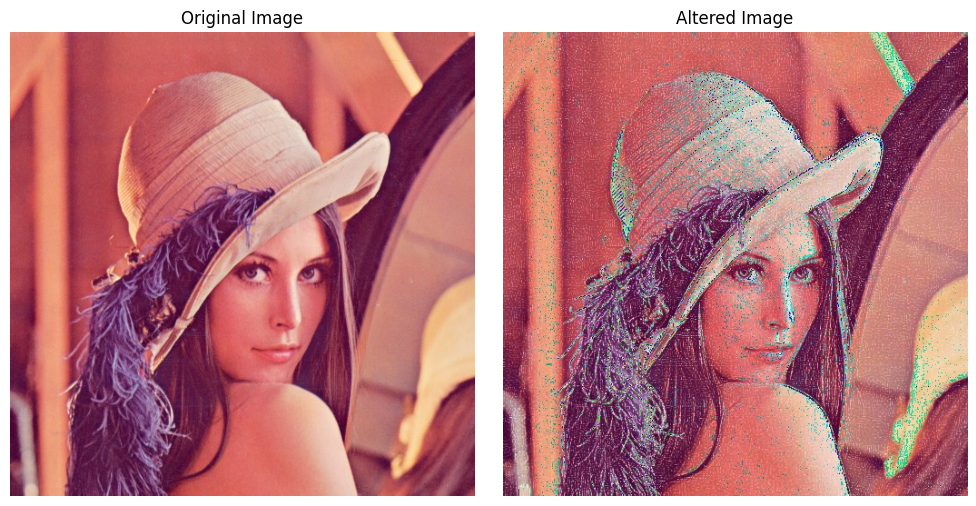

In [11]:
#Show the Images
fig, axes = plot.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(original, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(altered, cmap='gray')
axes[1].set_title('Altered Image')
axes[1].axis('off')

plot.tight_layout()
plot.show()

In [12]:
#Create a Hamming Distance Function
def hamming(hash1,hash2):
    L = len(hash1)
    distance = 0

    for i in range(L):
        if hash1[i] != hash2[i]:
            distance += 1

    return(str(distance))

In [13]:
#Calculate the Hash Md5, Sha1 and Sha256 Calc
md5_original = str(hashlib.md5(img1).hexdigest())
md5_alterada = str(hashlib.md5(img2).hexdigest())

sha1_original = str(hashlib.sha1(img1).hexdigest())
sha1_alterada = str(hashlib.sha1(img2).hexdigest())

sha256_original = str(hashlib.sha256(img1).hexdigest())
sha256_alterada = str(hashlib.sha256(img2).hexdigest())

In [14]:
#Average Hashing
ahash1 = str(imagehash.average_hash(Image.open(io.BytesIO(img1))))
ahash2 = str(imagehash.average_hash(Image.open(io.BytesIO(img2))))
ahash_dist = hamming(ahash1,ahash2)

In [15]:
#Perceptual Hashing
phash1 = str(imagehash.phash(Image.open(io.BytesIO(img1))))
phash2 = str(imagehash.phash(Image.open(io.BytesIO(img2))))
phash_dist = hamming(phash1,phash2)

In [16]:
#Difference Hashing
dhash1 = str(imagehash.dhash(Image.open(io.BytesIO(img1))))
dhash2 = str(imagehash.dhash(Image.open(io.BytesIO(img2))))
dhash_dist = hamming(dhash1,dhash2)

In [17]:
#HSV Color Hashing
hsvhash1 = str(imagehash.colorhash(Image.open(io.BytesIO(img1))))
hsvhash2 = str(imagehash.colorhash(Image.open(io.BytesIO(img2))))
hsvhash_dist = hamming(hsvhash1,hsvhash2)

In [18]:
#Wavelet Hashing
whash1 = str(imagehash.whash(Image.open(io.BytesIO(img1))))
whash2 = str(imagehash.whash(Image.open(io.BytesIO(img2))))
whash_dist = hamming(whash1,whash2)

In [19]:
#Crop-Resistant Hashing
crhash1 = imagehash.crop_resistant_hash(Image.open(io.BytesIO(img1)))
crhash2 = imagehash.crop_resistant_hash(Image.open(io.BytesIO(img2)))

ArrayImage01 = str(crhash1).split(',')
ArrayImage02 = str(crhash2).split(',')

if len(ArrayImage01) <= len(ArrayImage02):
    menor = len(ArrayImage01)
    maior = len(ArrayImage02)

    total = maior - menor
    for i in range(total):
        ArrayImage01.append('################')

elif len(ArrayImage02) < len(ArrayImage01):
    menor = len(ArrayImage02)
    maior = len(ArrayImage01)

    total = maior - menor
    for i in range(total):
        ArrayImage02.append('################')

In [20]:
#Calc the Crop-Resistance Hashing Hamming Distance Values
total = 0
for i in range(maior):

    distance = 0
    string1 = ArrayImage01[i]
    string2 = ArrayImage02[i]

    for n in range(len(string1)):
        if string1[n] != string2[n]:
            distance += 1

    total = total + distance
media = total / maior

print("Total of Reductions: " + str(maior) + " with the Original File")
print("Sum of Hamming Distances: " + str(total))
print("Mean Hamming Distances: " + str(media))

Total of Reductions: 8 with the Original File
Sum of Hamming Distances: 96
Mean Hamming Distances: 12.0


In [21]:
#Ajust the Dataframe to Show all Information Value
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

In [22]:
# Create a Disctionary and a Dataframe
resultados = {
    'Hash Algorithm': ['MD5', 'SHA-1', 'SHA-256', 'Average Hash', 'Perceptual Hash', 'Difference Hash', 'HSV Color Hash', 'Wavelet Hash', 'Crop-Resistant Hash'],
    'Original': [md5_original, sha1_original, sha256_original, ahash1, phash1, dhash1, hsvhash1, whash1, 'Array (Múltiplo)'],
    'Altered': [md5_alterada, sha1_alterada, sha256_alterada, ahash2, phash2, dhash2, hsvhash2, whash2, 'Array (Múltiplo)'],
    'Hamming Distance': ['N/A', 'N/A', 'N/A', ahash_dist, phash_dist, dhash_dist, hsvhash_dist, whash_dist, total]
}

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

,Hash Algorithm,Original,Altered,Hamming Distance
0,MD5,0eaf36d4881c513ca70b6684bfaa5b08,24aa3d32857e78a83e8445c50ac5efce,N/A
1,SHA-1,9a6d6e48b2e5d31eb9e2f38adb877140fa4b1538,a8a8486d44ac4bae115038bd41558edb4c8d7623,N/A
2,SHA-256,ebe926ee8951fd5e1282b0945f72c00125c33819a4584dcceb258dbe1c6a1149,6e8099909ea66726cb3779ab3ff0902582ae749993af68a5e9d710fe9f5956bc,N/A
3,Average Hash,b69cbd890b0b8f8c,b69cbd890b0b8f8c,0
4,Perceptual Hash,99c6562d7533a296,99c6562d7533a296,0
5,Difference Hash,7670795b33135a38,6470795b33135a38,2
6,HSV Color Hash,006000c0001,016000c0001,1
7,Wavelet Hash,be98bd890b0b8f8c,be98bd890b0b8f8c,0
8,Crop-Resistant Hash,Array (Múltiplo),Array (Múltiplo),96


In [23]:
# Fit the Data
data = {
    'Hash Algorithm': ['Average Hash', 'Perceptual Hash', 'Difference Hash', 'HSV Color Hash', 'Wavelet Hash', 'Crop-Resistant'],
    'Hamming Distance': [int(ahash_dist), int(phash_dist), int(dhash_dist), int(hsvhash_dist), int(whash_dist), int(media)]
}

df_final = pd.DataFrame(data)

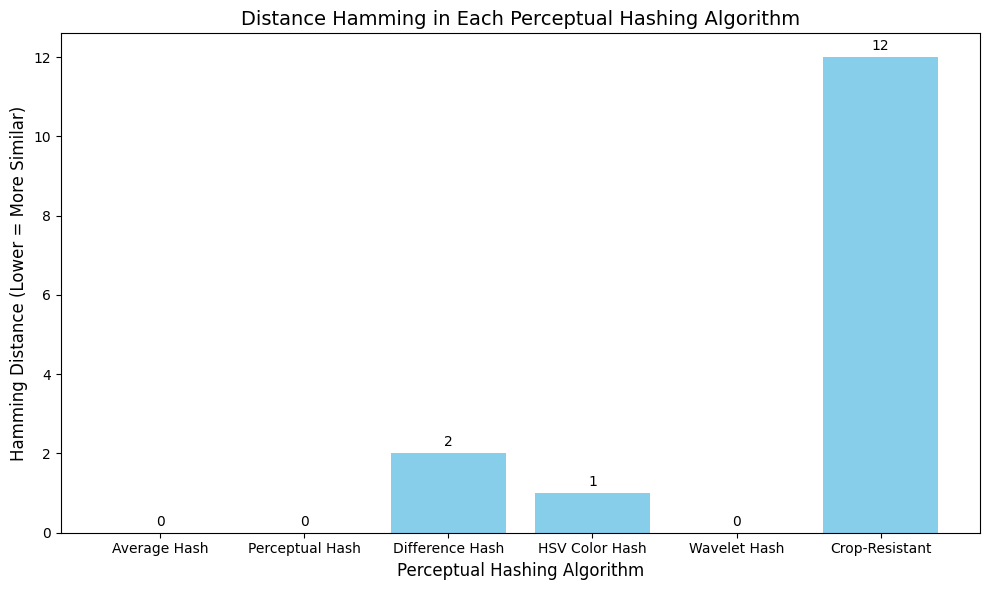

In [24]:
#Show the Distance in Graphics
plot.figure(figsize=(10, 6))
bars = plot.bar(df_final['Hash Algorithm'], df_final['Hamming Distance'], color='skyblue')
plot.title('Distance Hamming in Each Perceptual Hashing Algorithm', fontsize=14)
plot.xlabel('Perceptual Hashing Algorithm', fontsize=12)
plot.ylabel('Hamming Distance (Lower = More Similar)', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plot.text(bar.get_x() + bar.get_width()/2, yval + 0.1, yval, ha='center', va='bottom')

plot.tight_layout()
plot.show()